## Dados Públicos

Tarefas:
- Parte 1 — Cálculo e modelagem
- Calcule o custo total em BRL por transação
- Identifique transações com prejuízo
- Agregue os dados por id_produto, gerando:
- Receita total (BRL)
- Prejuízo total (BRL)
- Percentual de perda (prejuízo_total / receita_total)

In [2]:
import json
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import timedelta

# Vendas
df_vendas = pd.read_csv('../datasets/vendas_2023_2024.csv')
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], dayfirst=True, errors='coerce')
df_vendas = df_vendas.dropna(subset=['sale_date'])

# Custos
with open('../datasets/custos_importacao.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Desaninhar custos
rows = []
for produto in data:
    for h in produto['historic_data']:
        rows.append({
            'product_id':   produto['product_id'],
            'product_name': produto['product_name'],
            'start_date':   pd.to_datetime(h['start_date'], dayfirst=True),
            'usd_price':    h['usd_price']
        })

df_custos = pd.DataFrame(rows).sort_values(['product_id', 'start_date'])

print("Vendas:", df_vendas.shape)
print("Custos:", df_custos.shape)

Vendas: (1950, 6)
Custos: (1260, 4)


In [3]:
def buscar_cambio_bcb(data_inicio: str, data_fim: str) -> pd.DataFrame:
    """Busca cotação média de venda USD/BRL na API do Banco Central."""
    url = (
        "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
        f"CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)"
        f"?@dataInicial='{data_inicio}'&@dataFinalCotacao='{data_fim}'"
        "&$format=json&$select=cotacaoVenda,dataHoraCotacao"
    )
    resp = requests.get(url, timeout=30)
    registros = resp.json()['value']
    df = pd.DataFrame(registros)
    df['date'] = pd.to_datetime(df['dataHoraCotacao']).dt.date
    df['date'] = pd.to_datetime(df['date'])
    return df.groupby('date')['cotacaoVenda'].mean().reset_index().rename(columns={'cotacaoVenda': 'cambio'})

# Busca câmbio para todo o período das vendas
data_min = df_vendas['sale_date'].min().strftime('%m-%d-%Y')
data_max = df_vendas['sale_date'].max().strftime('%m-%d-%Y')

df_cambio = buscar_cambio_bcb(data_min, data_max)
print(f"Cotações obtidas: {len(df_cambio)} dias úteis")
df_cambio.head()

Cotações obtidas: 490 dias úteis


,date,cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


In [4]:
# Cria calendário completo e preenche dias sem cotação com o último valor disponível
datas = pd.DataFrame({'sale_date': pd.date_range(df_vendas['sale_date'].min(), df_vendas['sale_date'].max())})
datas = datas.merge(df_cambio.rename(columns={'date': 'sale_date'}), on='sale_date', how='left')
datas['cambio'] = datas['cambio'].ffill()

df_vendas = df_vendas.merge(datas, on='sale_date', how='left')
print(f"Vendas sem câmbio: {df_vendas['cambio'].isna().sum()}")
df_vendas.head()

Vendas sem câmbio: 5


,id,id_client,id_product,qtd,total,sale_date,cambio
0,0,42,105,11,3405.0,2023-10-09,5.1666
1,4,20,23,5,55893.0,2023-03-02,5.2080
2,5,8,57,4,451403.9,2024-12-02,6.0634
3,11,39,128,5,23254.0,2023-07-05,4.8577
4,17,43,91,11,1409558.7,2023-05-09,5.0007


In [5]:
def custo_vigente(product_id, sale_date):
    """Retorna o usd_price vigente na data da venda (última entrada <= sale_date)."""
    subset = df_custos[
        (df_custos['product_id'] == product_id) &
        (df_custos['start_date'] <= sale_date)
    ]
    if subset.empty:
        return None
    return subset.iloc[-1]['usd_price']

df_vendas['usd_price_unit'] = df_vendas.apply(
    lambda row: custo_vigente(row['id_product'], row['sale_date']), axis=1
)

print(f"Vendas sem custo mapeado: {df_vendas['usd_price_unit'].isna().sum()}")
df_vendas.head()

Vendas sem custo mapeado: 0


,id,id_client,id_product,qtd,total,sale_date,cambio,usd_price_unit
0,0,42,105,11,3405.0,2023-10-09,5.1666,62.64
1,4,20,23,5,55893.0,2023-03-02,5.2080,2108.74
2,5,8,57,4,451403.9,2024-12-02,6.0634,20486.78
3,11,39,128,5,23254.0,2023-07-05,4.8577,853.09
4,17,43,91,11,1409558.7,2023-05-09,5.0007,26303.31


In [6]:
# Custo total em BRL = custo unitário USD × qtd × câmbio do dia
df_vendas['custo_brl'] = df_vendas['usd_price_unit'] * df_vendas['qtd'] * df_vendas['cambio']

# Prejuízo = quando o custo supera a receita
df_vendas['prejuizo'] = df_vendas['custo_brl'] - df_vendas['total']
df_vendas['tem_prejuizo'] = df_vendas['prejuizo'] > 0

print(f"Transações com prejuízo: {df_vendas['tem_prejuizo'].sum()}")
df_vendas[df_vendas['tem_prejuizo']].head()

Transações com prejuízo: 1233


,id,id_client,id_product,qtd,total,sale_date,cambio,usd_price_unit,custo_brl,prejuizo,tem_prejuizo
0,0,42,105,11,3405.0,2023-10-09,5.1666,62.64,3.559994e+03,154.994064,True
2,5,8,57,4,451403.9,2024-12-02,6.0634,20486.78,4.968782e+05,45474.267408,True
4,17,43,91,11,1409558.7,2023-05-09,5.0007,26303.31,1.446885e+06,37325.885487,True
6,32,43,40,11,156024.0,2023-02-11,5.2526,2757.45,1.593216e+05,3297.600570,True
7,44,39,81,8,928328.6,2024-03-12,4.9813,23345.09,9.303112e+05,1982.574536,True


In [7]:
agg = df_vendas.groupby('id_product').agg(
    receita_total=('total', 'sum'),
    prejuizo_total=('prejuizo', lambda x: x[x > 0].sum())
).reset_index()

agg['pct_perda'] = (agg['prejuizo_total'] / agg['receita_total'] * 100).round(2)
agg = agg.sort_values('prejuizo_total', ascending=False)

print(f"Produtos com prejuízo: {(agg['prejuizo_total'] > 0).sum()}")
agg[agg['prejuizo_total'] > 0]

Produtos com prejuízo: 149


,id_product,receita_total,prejuizo_total,pct_perda
71,72,11546148.60,7.079825e+06,61.32
82,83,7319851.30,2.872185e+06,39.24
73,74,10603423.05,2.257131e+06,21.29
54,55,14276338.00,1.674992e+06,11.73
70,71,19109551.95,1.455565e+06,7.62
...,...,...,...,...
125,126,217511.10,1.284379e+03,0.59
145,146,39432.00,1.221347e+03,3.10
144,145,213143.00,1.172428e+03,0.55
113,114,72136.20,1.144785e+03,1.59


Parte 2 — Análise visual
- Gere um gráfico que represente o prejuízo total por produto, considerando apenas produtos que tiveram prejuízo. (Inserir o gráfico no relatório/dashboard final)

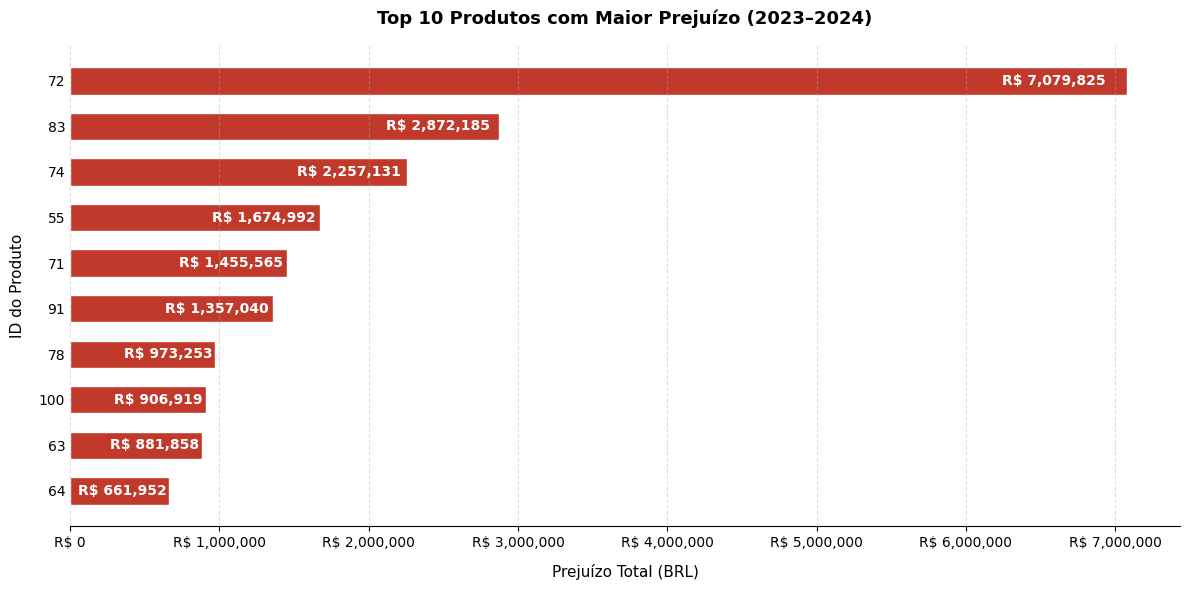

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Top 10 maiores prejuízos
df_plot = (agg[agg['prejuizo_total'] > 0]
           .sort_values('prejuizo_total', ascending=False)
           .head(10)
           .sort_values('prejuizo_total', ascending=True))  # invertido para barh

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    df_plot['id_product'].astype(str),
    df_plot['prejuizo_total'],
    color='#c0392b',
    edgecolor='white',
    height=0.6
)

# Labels dentro das barras
for bar, val in zip(bars, df_plot['prejuizo_total']):
    ax.text(
        bar.get_width() - bar.get_width() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {val:,.0f}',
        va='center', ha='right',
        color='white', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Prejuízo Total (BRL)', fontsize=11, labelpad=10)
ax.set_ylabel('ID do Produto', fontsize=11, labelpad=10)
ax.set_title('Top 10 Produtos com Maior Prejuízo (2023–2024)', fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.set_xlim(0, df_plot['prejuizo_total'].max() * 1.05)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()